In [1]:
# Cell 1: imports, operators, MPS class, canonicalization, observables

import os
import time
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import List, Tuple, Optional

from scipy.sparse.linalg import LinearOperator, eigsh
from scipy.optimize import curve_fit

np.set_printoptions(precision=6, suppress=True)

FIGDIR = "figureAKLT"
os.makedirs(FIGDIR, exist_ok=True)


# ============================================================
# Spin operators
# ============================================================

def spin_half_ops():
    I = np.eye(2, dtype=complex)
    Sp = np.array([[0, 1], [0, 0]], dtype=complex)
    Sm = np.array([[0, 0], [1, 0]], dtype=complex)
    Sz = np.array([[0.5, 0], [0, -0.5]], dtype=complex)
    Sx = 0.5 * (Sp + Sm)
    Sy = -0.5j * (Sp - Sm)
    return I, Sx, Sy, Sz, Sp, Sm


def spin_one_ops():
    I = np.eye(3, dtype=complex)
    Sp = np.array([
        [0, np.sqrt(2), 0],
        [0, 0, np.sqrt(2)],
        [0, 0, 0]
    ], dtype=complex)
    Sm = Sp.conj().T
    Sz = np.diag([1, 0, -1]).astype(complex)
    Sx = 0.5 * (Sp + Sm)
    Sy = -0.5j * (Sp - Sm)
    return I, Sx, Sy, Sz, Sp, Sm


# ============================================================
# MPS data structure
# ============================================================

@dataclass
class MPS:
    tensors: List[np.ndarray]   # shape (Dl, d, Dr)

    @property
    def L(self):
        return len(self.tensors)

    @property
    def d(self):
        return self.tensors[0].shape[1]

    def copy(self):
        return MPS([A.copy() for A in self.tensors])

    def bond_dimensions(self):
        dims = [self.tensors[0].shape[0]]
        for A in self.tensors:
            dims.append(A.shape[2])
        return dims

    def print_shapes(self):
        for i, A in enumerate(self.tensors):
            print(f"site {i}: {A.shape}")

    def norm_sq(self):
        env = np.ones((1, 1), dtype=complex)
        for M in self.tensors:
            env = np.einsum('xy,xsz,ysw->zw', env, M, M.conj(), optimize=True)
        return float(np.real(env[0, 0]))

    def normalize(self):
        n2 = self.norm_sq()
        if np.isfinite(n2) and n2 > 0:
            self.tensors[-1] = self.tensors[-1] / np.sqrt(n2)
        return self


# ============================================================
# Random MPS
# ============================================================

def random_mps(L: int, d: int, Dmax: int, seed: Optional[int] = None) -> MPS:
    rng = np.random.default_rng(seed)

    bond_dims = [1]
    for i in range(1, L):
        bond_dims.append(min(Dmax, d**i, d**(L - i)))
    bond_dims.append(1)

    tensors = []
    for i in range(L):
        Dl, Dr = bond_dims[i], bond_dims[i + 1]
        A = rng.normal(size=(Dl, d, Dr)) + 1j * rng.normal(size=(Dl, d, Dr))
        A /= np.linalg.norm(A)
        tensors.append(A.astype(complex))

    return MPS(tensors)


# ============================================================
# Canonicalization
# C-order reshape exactly as in the note
# ============================================================

def left_canonicalize(mps: MPS) -> Tuple[MPS, np.ndarray]:
    tensors = [A.copy() for A in mps.tensors]
    L = len(tensors)
    C = np.array([[1.0 + 0.0j]])

    for i in range(L - 1):
        M = tensors[i]
        Dl, d, Dr = M.shape

        M_eff = np.einsum('ab,bsd->asd', C, M, optimize=True)
        M_tilde = M_eff.reshape((Dl * d, Dr), order='C')

        Q, R = np.linalg.qr(M_tilde, mode='reduced')
        k = Q.shape[1]

        tensors[i] = Q.reshape((Dl, d, k), order='C')
        C = R
        tensors[i + 1] = np.einsum('ab,bsd->asd', C, tensors[i + 1], optimize=True)

    return MPS(tensors), C


def right_canonicalize(mps: MPS) -> MPS:
    tensors = [A.copy() for A in mps.tensors]
    L = len(tensors)
    C = np.array([[1.0 + 0.0j]])

    for i in range(L - 1, 0, -1):
        M = tensors[i]
        Dl, d, Dr = M.shape

        M_eff = np.einsum('asd,db->asb', M, C, optimize=True)
        M_tilde = M_eff.reshape((Dl, d * Dr), order='C')

        Q, R = np.linalg.qr(M_tilde.T, mode='reduced')
        k = Q.shape[1]

        tensors[i] = Q.T.reshape((k, d, Dr), order='C')
        C = R.T
        tensors[i - 1] = np.einsum('asd,db->asb', tensors[i - 1], C, optimize=True)

    return MPS(tensors)


def bring_to_bond(mps: MPS, k: int) -> MPS:
    tensors = [A.copy() for A in mps.tensors]
    L = len(tensors)

    C = np.array([[1.0 + 0.0j]])
    for i in range(0, k + 1):
        if i == L - 1:
            tensors[i] = np.einsum('ab,bsd->asd', C, tensors[i], optimize=True)
            break
        M = np.einsum('ab,bsd->asd', C, tensors[i], optimize=True)
        Dl, d, Dr = M.shape
        X = M.reshape((Dl * d, Dr), order='C')
        Q, R = np.linalg.qr(X, mode='reduced')
        kk = Q.shape[1]
        tensors[i] = Q.reshape((Dl, d, kk), order='C')
        C = R

    if k + 1 < L:
        tensors[k + 1] = np.einsum('ab,bsd->asd', C, tensors[k + 1], optimize=True)

    C = np.array([[1.0 + 0.0j]])
    for i in range(L - 1, k, -1):
        M = np.einsum('asd,db->asb', tensors[i], C, optimize=True)
        Dl, d, Dr = M.shape
        X = M.reshape((Dl, d * Dr), order='C')
        Q, R = np.linalg.qr(X.T, mode='reduced')
        kk = Q.shape[1]
        tensors[i] = Q.T.reshape((kk, d, Dr), order='C')
        C = R.T
        tensors[i - 1] = np.einsum('asd,db->asb', tensors[i - 1], C, optimize=True)

    return MPS(tensors)


def test_left_canonical(A, atol=1e-12):
    Dl, d, Dr = A.shape
    X = A.reshape(Dl * d, Dr, order='C')
    return np.allclose(X.conj().T @ X, np.eye(Dr), atol=atol)


def test_right_canonical(B, atol=1e-12):
    Dl, d, Dr = B.shape
    X = B.reshape(Dl, d * Dr, order='C')
    return np.allclose(X @ X.conj().T, np.eye(Dl), atol=atol)


# ============================================================
# Truncation
# ============================================================

def truncate_bond(M, Dmax, eps=1e-10, eps_abs=1e-14):
    M = np.asarray(M, dtype=complex)
    if not np.all(np.isfinite(M)):
        M = np.nan_to_num(M, nan=0.0, posinf=0.0, neginf=0.0)

    U, s, Vh = np.linalg.svd(M, full_matrices=False)

    if len(s) == 0:
        U = np.zeros((M.shape[0], 1), dtype=complex)
        U[0, 0] = 1.0
        s = np.array([0.0])
        Vh = np.zeros((1, M.shape[1]), dtype=complex)
        if M.shape[1] > 0:
            Vh[0, 0] = 1.0
        return U, s, Vh

    if s[0] < eps_abs:
        D = 1
    else:
        threshold = max(eps * s[0], eps_abs)
        D = max(1, min(Dmax, int(np.sum(s > threshold))))

    return U[:, :D], s[:D], Vh[:D, :]


# ============================================================
# Observables
# ============================================================

def expectation(mps: MPS, op: np.ndarray, site: int) -> float:
    env = np.ones((1, 1), dtype=complex)
    for i in range(mps.L):
        M = mps.tensors[i]
        if i == site:
            env = np.einsum('xy,xsz,st,ytw->zw', env, M, op, M.conj(), optimize=True)
        else:
            env = np.einsum('xy,xsz,ysw->zw', env, M, M.conj(), optimize=True)
    return float(np.real(env[0, 0]))


def correlator(mps: MPS, op1: np.ndarray, op2: np.ndarray, i: int, j: int) -> float:
    if i > j:
        i, j = j, i
        op1, op2 = op2, op1

    env = np.ones((1, 1), dtype=complex)
    for k in range(mps.L):
        M = mps.tensors[k]
        if k == i:
            env = np.einsum('xy,xsz,st,ytw->zw', env, M, op1, M.conj(), optimize=True)
        elif k == j:
            env = np.einsum('xy,xsz,st,ytw->zw', env, M, op2, M.conj(), optimize=True)
        else:
            env = np.einsum('xy,xsz,ysw->zw', env, M, M.conj(), optimize=True)
    return float(np.real(env[0, 0]))


def string_order_parameter(mps: MPS, Sz: np.ndarray, i: int, j: int) -> float:
    if i >= j:
        raise ValueError("Require i < j")

    string_op = np.diag(np.exp(1j * np.pi * np.diag(Sz))).astype(complex)

    env = np.ones((1, 1), dtype=complex)
    for k in range(mps.L):
        M = mps.tensors[k]
        if k == i:
            env = np.einsum('xy,xsz,st,ytw->zw', env, M, Sz, M.conj(), optimize=True)
        elif i < k < j:
            env = np.einsum('xy,xsz,st,ytw->zw', env, M, string_op, M.conj(), optimize=True)
        elif k == j:
            env = np.einsum('xy,xsz,st,ytw->zw', env, M, Sz, M.conj(), optimize=True)
        else:
            env = np.einsum('xy,xsz,ysw->zw', env, M, M.conj(), optimize=True)
    return float(np.real(env[0, 0]))


def schmidt_values_at_bond(mps: MPS, b: int):
    if not (1 <= b <= mps.L - 1):
        raise ValueError("bond b must satisfy 1 <= b <= L-1")

    psi = bring_to_bond(mps, b - 1)
    M = psi.tensors[b]
    Dl, d, Dr = M.shape
    X = M.reshape(Dl, d * Dr, order='C')
    _, s, _ = np.linalg.svd(X, full_matrices=False)
    s = np.maximum(np.real_if_close(s), 0.0)
    nrm = np.linalg.norm(s)
    if nrm > 0:
        s = s / nrm
    return s


def entanglement_entropy(mps: MPS, b: int, cutoff=1e-15) -> float:
    s = schmidt_values_at_bond(mps, b)
    p = s**2
    p = p[p > cutoff]
    return float(-np.sum(p * np.log(p)))


def entanglement_profile(mps: MPS):
    return np.array([entanglement_entropy(mps, b) for b in range(1, mps.L)])

In [2]:
# Cell 2: MPOs, environments, exact checks

# ============================================================
# Heisenberg MPO
# Strictly the analytical MPO convention in the note
# ============================================================

def build_heisenberg_mpo(L, Jx=1.0, Jy=1.0, Jz=1.0, h=0.0):
    """
    Uses the note's 5x5 MPO in terms of S+, S-, Sz.
    In this implementation we follow the note's form:
      H = sum_i [ (Jx/2)(S+S- + S-S+) + Jz SzSz ] + h sum_i Sz
    For isotropic S=1/2 Heisenberg, use Jx=Jz=1.
    """
    I, Sx, Sy, Sz, Sp, Sm = spin_half_ops()
    d = 2
    D_W = 5

    W = np.zeros((D_W, D_W, d, d), dtype=complex)
    W[0, 0] = I
    W[1, 0] = Sp
    W[2, 0] = Sm
    W[3, 0] = Sz

    W[4, 0] = h * Sz
    W[4, 1] = 0.5 * Jx * Sm
    W[4, 2] = 0.5 * Jx * Sp
    W[4, 3] = Jz * Sz
    W[4, 4] = I

    W_L = W[4:5, :, :, :]
    W_R = W[:, 0:1, :, :]

    mpo = [W_L] + [W.copy() for _ in range(L - 2)] + [W_R]
    return mpo, D_W


# ============================================================
# AKLT MPO from SVD of the two-site kernel
# ============================================================

def build_aklt_two_site_kernel():
    I, Sx, Sy, Sz, Sp, Sm = spin_one_ops()
    d = 3

    SS = (
        np.einsum('ij,kl->ikjl', Sz, Sz, optimize=True)
        + 0.5 * np.einsum('ij,kl->ikjl', Sp, Sm, optimize=True)
        + 0.5 * np.einsum('ij,kl->ikjl', Sm, Sp, optimize=True)
    )
    SS_mat = SS.reshape(d * d, d * d)
    H2_mat = SS_mat + (1.0 / 3.0) * (SS_mat @ SS_mat)

    H2_r = H2_mat.reshape(d, d, d, d).transpose(0, 2, 1, 3)
    H2_4 = H2_mat.reshape(d, d, d, d)
    return H2_4, H2_r


def build_aklt_mpo(L, svd_tol=1e-12, verbose=True):
    I, Sx, Sy, Sz, Sp, Sm = spin_one_ops()
    d = 3

    H2_4, H2_r = build_aklt_two_site_kernel()

    U, sv, Vt = np.linalg.svd(H2_r.reshape(d * d, d * d), full_matrices=False)
    r = int(np.sum(sv > svd_tol))
    sqsv = np.sqrt(sv[:r])

    A = (U[:, :r] * sqsv[None, :]).T.reshape(r, d, d)
    B = (Vt[:r, :] * sqsv[:, None]).reshape(r, d, d)

    H2_rec = np.einsum('kij,klm->ijlm', A, B, optimize=True)
    decomp_err = np.max(np.abs(H2_rec - H2_r))

    D_W = r + 2
    W = np.zeros((D_W, D_W, d, d), dtype=complex)

    W[0, 0] = I
    W[r + 1, r + 1] = I
    for k in range(r):
        W[r + 1, k + 1] = A[k]
        W[k + 1, 0] = B[k]

    W_L = W[r + 1:r + 2, :, :, :]
    W_R = W[:, 0:1, :, :]

    H2_check = np.einsum('ibsS,bjtT->sStT', W_L, W_R, optimize=True)
    mpo_err = np.max(np.abs(H2_check - H2_r))

    if verbose:
        print("AKLT two-site SVD rank r =", r)
        print("AKLT decomposition max error =", decomp_err)
        print("AKLT MPO two-site max error  =", mpo_err)
        print("AKLT MPO tensor shapes:")
        print("  left :", W_L.shape)
        if L > 2:
            print("  bulk :", W.shape)
        print("  right:", W_R.shape)

    mpo = [W_L] + [W.copy() for _ in range(L - 2)] + [W_R]
    info = {
        "rank": r,
        "decomp_err": decomp_err,
        "mpo_err": mpo_err,
        "H2_r": H2_r,
        "A": A,
        "B": B,
    }
    return mpo, D_W, info


def mpo_two_site_check(W_L, W_R, H2_exact):
    H2_check = np.einsum('ibsS,bjtT->sStT', W_L, W_R, optimize=True)
    err = np.max(np.abs(H2_check - H2_exact))
    return err, H2_check


# ============================================================
# Environment updates from the note
# ============================================================

def update_left_environment(Lenv, M, W):
    return np.einsum('axu,xsz,aBsS,uSv->Bzv',
                     Lenv, M, W, M.conj(), optimize=True)


def update_right_environment(Renv, M, W):
    return np.einsum('Bzv,xsz,aBsS,uSv->axu',
                     Renv, M, W, M.conj(), optimize=True)


def build_all_right_environments(mps: MPS, mpo: List[np.ndarray]):
    L = mps.L
    R = [None] * (L + 1)
    R[L] = np.ones((1, 1, 1), dtype=complex)

    for i in range(L - 1, -1, -1):
        R[i] = update_right_environment(R[i + 1], mps.tensors[i], mpo[i])

    return R


def build_all_left_environments(mps: MPS, mpo: List[np.ndarray]):
    L = mps.L
    Lenvs = [None] * (L + 1)
    Lenvs[0] = np.ones((1, 1, 1), dtype=complex)

    for i in range(L):
        Lenvs[i + 1] = update_left_environment(Lenvs[i], mps.tensors[i], mpo[i])

    return Lenvs


def mpo_expectation_value(mps: MPS, mpo: List[np.ndarray]) -> float:
    env = np.ones((1, 1, 1), dtype=complex)
    for i in range(mps.L):
        env = update_left_environment(env, mps.tensors[i], mpo[i])
    return float(np.real(env[0, 0, 0]))


# ============================================================
# Quick checks
# ============================================================

print("Running Cell 2 checks...")

mpo_aklt_test, DW_aklt_test, aklt_info_test = build_aklt_mpo(6, verbose=True)
assert aklt_info_test["rank"] == 9
assert aklt_info_test["decomp_err"] < 1e-12
assert aklt_info_test["mpo_err"] < 1e-12

err2, _ = mpo_two_site_check(mpo_aklt_test[0], mpo_aklt_test[-1], aklt_info_test["H2_r"])
assert err2 < 1e-12

mpo_heis_test, DW_heis_test = build_heisenberg_mpo(6, Jx=1.0, Jy=1.0, Jz=1.0, h=0.0)
assert DW_heis_test == 5

print("Cell 2 completed successfully.")

Running Cell 2 checks...
AKLT two-site SVD rank r = 9
AKLT decomposition max error = 4.440892098500626e-16
AKLT MPO two-site max error  = 4.440892098500626e-16
AKLT MPO tensor shapes:
  left : (1, 11, 3, 3)
  bulk : (11, 11, 3, 3)
  right: (11, 1, 3, 3)
Cell 2 completed successfully.


In [3]:
# Cell 3: strictly matrix-free two-site DMRG with robust Lanczos startup

# ============================================================
# Two-site matvec
# Literal note indices
# ============================================================

def two_site_matvec(Lenv, Renv, Wi, Wj, theta_vec, Dl, d, Dr):
    """
    Theta[x, s, t, z]
    Lenv[a, x, u]
    Wi[a, b, s, S]
    Wj[b, B, t, T]
    Renv[B, z, v]

    Step 1:
      T[u, b, S, t, z] = einsum('axu,xstz,absS->ubStz', Lenv, Theta, Wi)

    Step 2:
      out[u, S, T, v]  = einsum('ubStz,bBtT,Bzv->uSTv', T, Wj, Renv)
    """
    Theta = theta_vec.reshape((Dl, d, d, Dr), order='C')

    T = np.einsum('axu,xstz,absS->ubStz',
                  Lenv, Theta, Wi, optimize=True)

    out = np.einsum('ubStz,bBtT,Bzv->uSTv',
                    T, Wj, Renv, optimize=True)

    return out.reshape(-1, order='C')


# ============================================================
# Local canonicalization after optimization
# ============================================================

def left_canonicalize_site_and_absorb(Mi, Mj):
    Dl, d, Dr = Mi.shape
    X = Mi.reshape((Dl * d, Dr), order='C')
    Q, R = np.linalg.qr(X, mode='reduced')
    k = Q.shape[1]

    Mi_new = Q.reshape((Dl, d, k), order='C')
    Mj_new = np.einsum('ab,bsd->asd', R, Mj, optimize=True)
    return Mi_new, Mj_new


def right_canonicalize_site_and_absorb(Mi, Mj):
    Dl, d, Dr = Mj.shape
    X = Mj.reshape((Dl, d * Dr), order='C')
    Q, R = np.linalg.qr(X.T, mode='reduced')
    k = Q.shape[1]

    Mj_new = Q.T.reshape((k, d, Dr), order='C')
    Mi_new = np.einsum('asd,db->asb', Mi, R.T, optimize=True)
    return Mi_new, Mj_new


# ============================================================
# Robust Lanczos start vector
# ============================================================

def _safe_start_vector(v, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    v = np.asarray(v, dtype=complex).copy()
    nrm = np.linalg.norm(v)

    if np.isfinite(nrm) and nrm > 0:
        return v / nrm

    # fallback random vector
    vr = rng.normal(size=v.shape[0]) + 1j * rng.normal(size=v.shape[0])
    nr = np.linalg.norm(vr)
    if nr == 0:
        vr[0] = 1.0
        nr = 1.0
    return vr / nr


# ============================================================
# Strictly matrix-free local optimization
# ============================================================

def optimize_two_site(Mi, Mj, Lenv, Renv, Wi, Wj,
                      Dmax, eps_trunc=1e-10, eps_abs=1e-14,
                      lanczos_ncv=None, lanczos_tol=1e-10, lanczos_maxiter=None,
                      rng=None):
    Dl, d, Dm = Mi.shape
    Dm2, d2, Dr = Mj.shape
    assert Dm == Dm2
    assert d == d2

    Theta0 = np.einsum('ijk,klm->ijlm', Mi, Mj, optimize=True)
    n = Dl * d * d * Dr
    v0 = _safe_start_vector(Theta0.reshape(-1, order='C'), rng=rng)

    Hlin = LinearOperator(
        shape=(n, n),
        matvec=lambda v: two_site_matvec(Lenv, Renv, Wi, Wj, v, Dl, d, Dr),
        dtype=np.complex128
    )

    if lanczos_ncv is None:
        lanczos_ncv = min(n, max(20, 10))

    # try once with current theta, retry once with random if ARPACK fails
    try:
        evals, evecs = eigsh(
            Hlin,
            k=1,
            which='SA',
            v0=v0,
            tol=lanczos_tol,
            maxiter=lanczos_maxiter,
            ncv=lanczos_ncv
        )
    except Exception:
        v0_retry = _safe_start_vector(np.zeros(n, dtype=complex), rng=rng)
        evals, evecs = eigsh(
            Hlin,
            k=1,
            which='SA',
            v0=v0_retry,
            tol=lanczos_tol,
            maxiter=lanczos_maxiter,
            ncv=lanczos_ncv
        )

    E0 = float(np.real(evals[0]))
    theta_opt = evecs[:, 0]

    theta_norm = np.linalg.norm(theta_opt)
    if (not np.isfinite(theta_norm)) or (theta_norm <= 0.0):
        theta_opt = _safe_start_vector(np.zeros(n, dtype=complex), rng=rng)
    else:
        theta_opt = theta_opt / theta_norm

    Theta_opt = theta_opt.reshape((Dl * d, d * Dr), order='C')
    U, s, Vh = truncate_bond(Theta_opt, Dmax=Dmax, eps=eps_trunc, eps_abs=eps_abs)
    Dnew = len(s)

    Mi_new = U.reshape((Dl, d, Dnew), order='C')
    Mj_new = (np.diag(s) @ Vh).reshape((Dnew, d, Dr), order='C')

    Hv = two_site_matvec(Lenv, Renv, Wi, Wj, theta_opt, Dl, d, Dr)
    denom = np.vdot(theta_opt, theta_opt)
    if np.abs(denom) > 0:
        E_rayleigh = float(np.real(np.vdot(theta_opt, Hv) / denom))
    else:
        E_rayleigh = E0

    info = {
        "solver": "eigsh",
        "n_local": n,
        "Dnew": Dnew,
        "singular_values": s.copy(),
        "E_rayleigh": E_rayleigh
    }
    return Mi_new, Mj_new, E0, info


# ============================================================
# Main two-site DMRG loop
# Correctness-first environment refresh
# ============================================================

def dmrg_two_site(mps_init: MPS,
                  mpo: List[np.ndarray],
                  Dmax: int,
                  nsweeps: int = 10,
                  eps_E: float = 1e-10,
                  eps_trunc: float = 1e-10,
                  eps_abs: float = 1e-14,
                  lanczos_tol: float = 1e-10,
                  lanczos_maxiter: Optional[int] = None,
                  verbose: bool = True,
                  seed: Optional[int] = 12345):
    """
    Strictly matrix-free DMRG:
      - local effective Hamiltonian only via LinearOperator + eigsh
      - never build dense Heff
    """
    rng = np.random.default_rng(seed)
    mps = right_canonicalize(mps_init.copy())

    L = mps.L
    E_prev = None

    history = {
        "sweep": [],
        "energy": [],
        "deltaE": [],
        "time": [],
        "solver_counts": []
    }

    for sweep in range(1, nsweeps + 1):
        t0 = time.time()
        solver_counts = {"eigsh": 0}

        # Left-to-right
        for i in range(0, L - 1):
            Lenv = np.ones((1, 1, 1), dtype=complex)
            for k in range(i):
                Lenv = update_left_environment(Lenv, mps.tensors[k], mpo[k])

            Renvs = build_all_right_environments(mps, mpo)
            Renv = Renvs[i + 2]

            Mi = mps.tensors[i]
            Mj = mps.tensors[i + 1]
            Wi = mpo[i]
            Wj = mpo[i + 1]

            Mi_opt, Mj_opt, E, info = optimize_two_site(
                Mi, Mj, Lenv, Renv, Wi, Wj,
                Dmax=Dmax,
                eps_trunc=eps_trunc,
                eps_abs=eps_abs,
                lanczos_tol=lanczos_tol,
                lanczos_maxiter=lanczos_maxiter,
                rng=rng
            )
            solver_counts["eigsh"] += 1

            Mi_new, Mj_new = left_canonicalize_site_and_absorb(Mi_opt, Mj_opt)
            mps.tensors[i] = Mi_new
            mps.tensors[i + 1] = Mj_new

        # Right-to-left
        for i in range(L - 2, -1, -1):
            Lenv = np.ones((1, 1, 1), dtype=complex)
            for k in range(i):
                Lenv = update_left_environment(Lenv, mps.tensors[k], mpo[k])

            Renvs = build_all_right_environments(mps, mpo)
            Renv = Renvs[i + 2]

            Mi = mps.tensors[i]
            Mj = mps.tensors[i + 1]
            Wi = mpo[i]
            Wj = mpo[i + 1]

            Mi_opt, Mj_opt, E, info = optimize_two_site(
                Mi, Mj, Lenv, Renv, Wi, Wj,
                Dmax=Dmax,
                eps_trunc=eps_trunc,
                eps_abs=eps_abs,
                lanczos_tol=lanczos_tol,
                lanczos_maxiter=lanczos_maxiter,
                rng=rng
            )
            solver_counts["eigsh"] += 1

            Mi_new, Mj_new = right_canonicalize_site_and_absorb(Mi_opt, Mj_opt)
            mps.tensors[i] = Mi_new
            mps.tensors[i + 1] = Mj_new

        nrm2 = mps.norm_sq()
        dt = time.time() - t0
        dE = np.inf if E_prev is None else abs(E - E_prev)

        history["sweep"].append(sweep)
        history["energy"].append(E)
        history["deltaE"].append(dE)
        history["time"].append(dt)
        history["solver_counts"].append(solver_counts.copy())

        if verbose:
            print(f"sweep {sweep:2d} | E = {E:.12f} | |dE| = {dE:.3e} | norm^2 = {nrm2:.6e} | time = {dt:.2f}s | solvers = {solver_counts}")

        if (E_prev is not None) and (dE < eps_E) and (sweep >= 3):
            if verbose:
                print("DMRG converged.")
            break

        E_prev = E

    mps.normalize()
    return mps, E, history


# ============================================================
# Quick AKLT sanity test
# ============================================================

print("Running Cell 3 AKLT sanity test...")

mpo_test, _, _ = build_aklt_mpo(8, verbose=False)
mps_test = random_mps(L=8, d=3, Dmax=4, seed=22)

mps_out, E_out, hist_out = dmrg_two_site(
    mps_test,
    mpo_test,
    Dmax=4,
    nsweeps=4,
    eps_E=1e-10,
    lanczos_tol=1e-10,
    verbose=True,
    seed=2024
)

print("AKLT test energy =", E_out)
print("AKLT exact       =", -(2.0/3.0)*(8-1))
print("Cell 3 completed successfully.")

Running Cell 3 AKLT sanity test...
sweep  1 | E = -4.666666619913 | |dE| = inf | norm^2 = 1.000000e+00 | time = 0.25s | solvers = {'eigsh': 14}
sweep  2 | E = -4.666666666667 | |dE| = 4.675e-08 | norm^2 = 1.000000e+00 | time = 0.15s | solvers = {'eigsh': 14}
sweep  3 | E = -4.666666666667 | |dE| = 2.665e-15 | norm^2 = 1.000000e+00 | time = 0.15s | solvers = {'eigsh': 14}
DMRG converged.
AKLT test energy = -4.666666666666669
AKLT exact       = -4.666666666666666
Cell 3 completed successfully.


Building AKLT MPO...
AKLT two-site SVD rank r = 9
AKLT decomposition max error = 4.440892098500626e-16
AKLT MPO two-site max error  = 4.440892098500626e-16
AKLT MPO tensor shapes:
  left : (1, 11, 3, 3)
  bulk : (11, 11, 3, 3)
  right: (11, 1, 3, 3)

Initializing random AKLT MPS...

Running AKLT DMRG...
sweep  1 | E = -12.666666563916 | |dE| = inf | norm^2 = 1.000000e+00 | time = 0.93s | solvers = {'eigsh': 38}
sweep  2 | E = -12.666666666667 | |dE| = 1.028e-07 | norm^2 = 1.000000e+00 | time = 0.71s | solvers = {'eigsh': 38}
sweep  3 | E = -12.666666666667 | |dE| = 2.842e-14 | norm^2 = 1.000000e+00 | time = 0.60s | solvers = {'eigsh': 38}
DMRG converged.

AKLT final results
  Final DMRG energy = -12.666666666666694
  Exact energy      = -12.666666666666666
  Energy per bond   = -0.6666666666666682
  Exact per bond    = -0.6666666666666666
  Abs error         = 2.842170943040401e-14


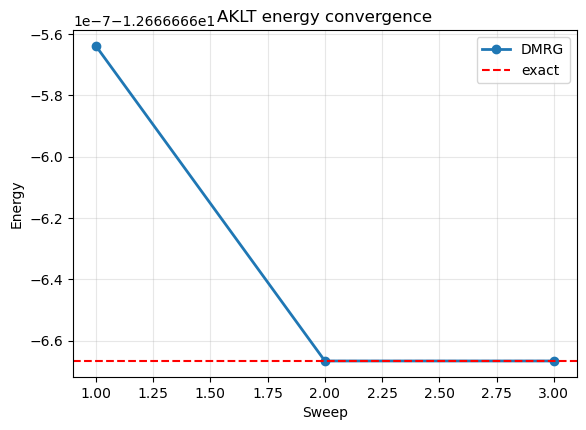

Saved: figureAKLT\01_energy_convergence.png


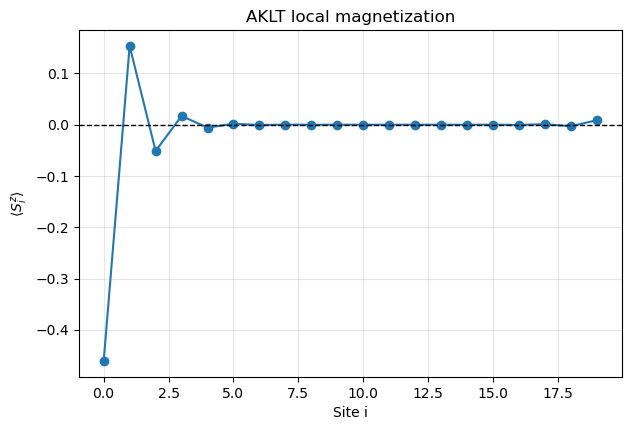

Saved: figureAKLT\02_local_Sz.png


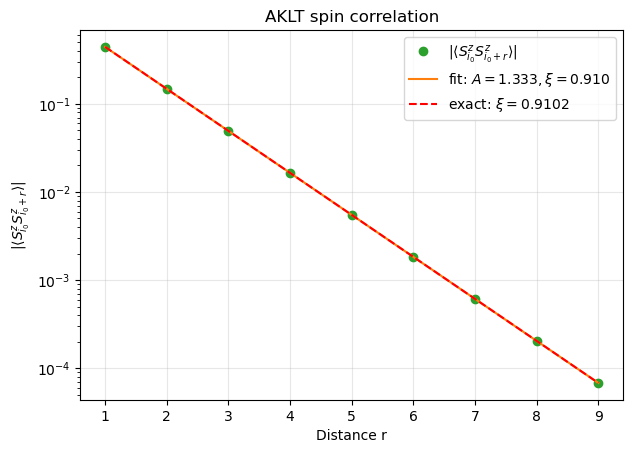

Saved: figureAKLT\03_spin_correlation.png


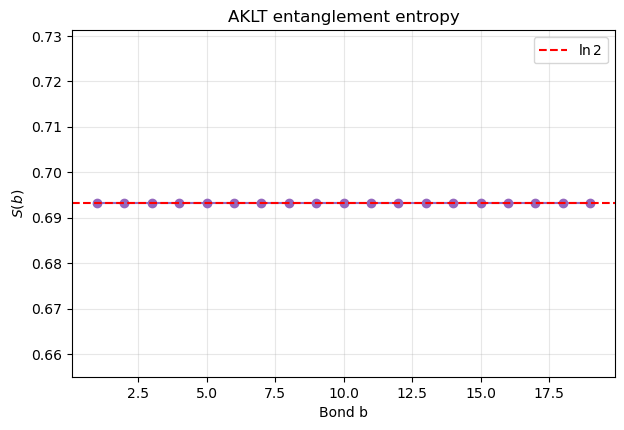

Saved: figureAKLT\04_entanglement_entropy.png


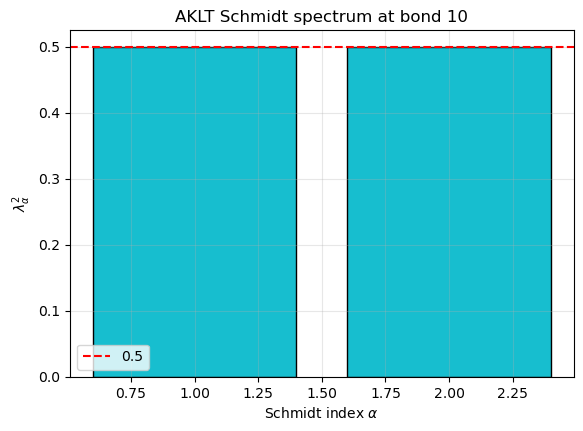

Saved: figureAKLT\05_schmidt_spectrum.png


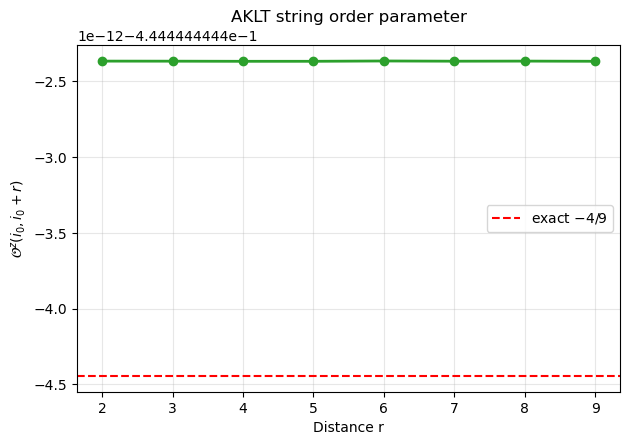

Saved: figureAKLT\06_string_order.png


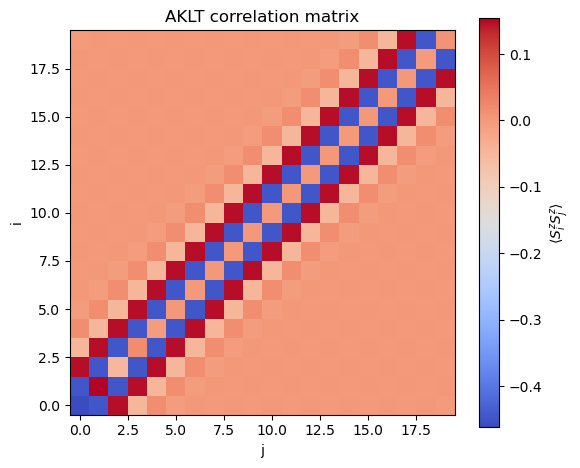

Saved: figureAKLT\09_correlation_matrix.png


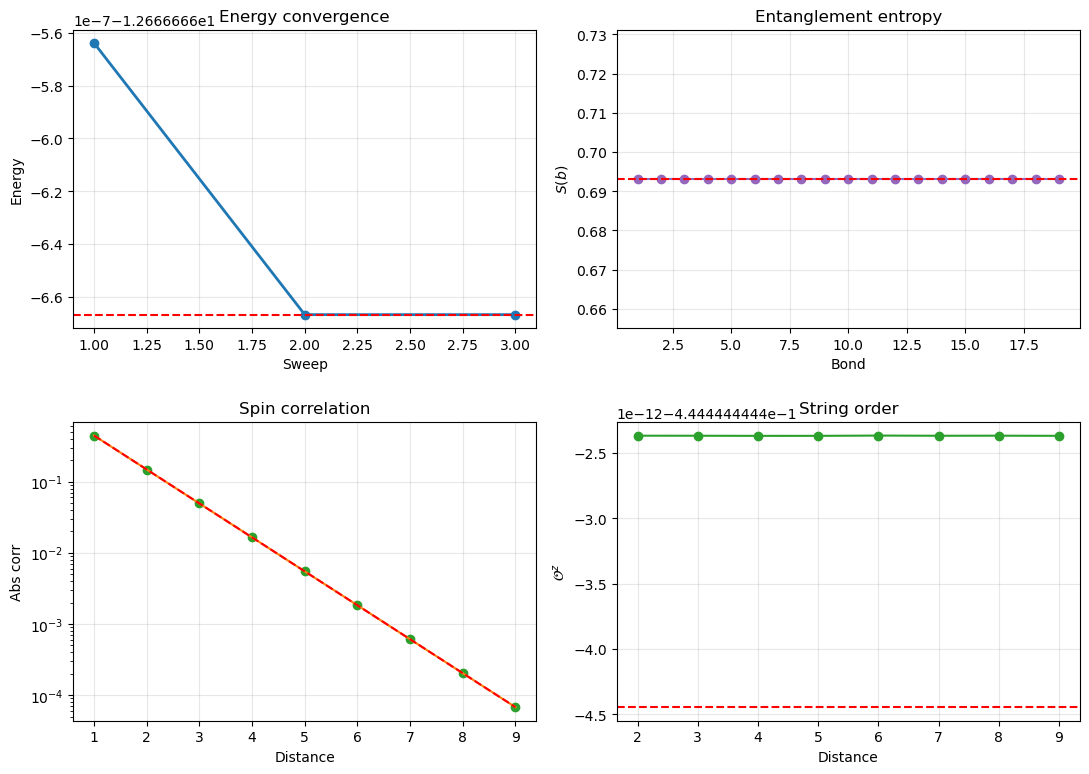

Saved: figureAKLT\10_summary_panel.png


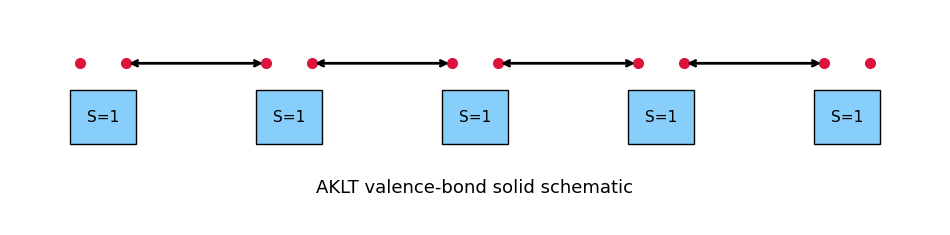

Saved: figureAKLT\11_vbs_schematic.png

AKLT numerical summary
------------------------------------------------------------
L = 20, Dmax = 5, DW = 11
Final energy                = -12.666666666667
Exact energy                = -12.666666666667
Energy per bond             = -0.666666666667
Exact energy per bond       = -0.666666666667
Absolute energy error       = 2.842e-14
Center entropy S(10) = 0.693147180560
Exact ln 2                  = 0.693147180560
Fitted correlation length   = 0.910239
Exact correlation length    = 0.910239
String order values         = [-0.444444 -0.444444 -0.444444 -0.444444 -0.444444 -0.444444 -0.444444
 -0.444444]
Center Schmidt weights      = [0.5 0.5]


In [4]:
# Cell 4: AKLT production run and AKLT figures

def save_show(fig, filename):
    path = os.path.join(FIGDIR, filename)
    fig.savefig(path, dpi=180, bbox_inches='tight')
    plt.show()
    print(f"Saved: {path}")


def exp_decay(r, A, xi):
    return A * np.exp(-r / xi)


# ============================================================
# AKLT production run
# ============================================================

L_aklt = 20
D_aklt = 5
nsweeps_aklt = 6
seed_aklt = 1234

print("Building AKLT MPO...")
mpo_aklt, DW_aklt, aklt_info = build_aklt_mpo(L_aklt, verbose=True)

print("\nInitializing random AKLT MPS...")
mps0_aklt = random_mps(L=L_aklt, d=3, Dmax=D_aklt, seed=seed_aklt)

print("\nRunning AKLT DMRG...")
mps_aklt, E_aklt, hist_aklt = dmrg_two_site(
    mps0_aklt,
    mpo_aklt,
    Dmax=D_aklt,
    nsweeps=nsweeps_aklt,
    eps_E=1e-12,
    eps_trunc=1e-12,
    eps_abs=1e-14,
    lanczos_tol=1e-12,
    verbose=True
)

E_exact_aklt = -(2.0 / 3.0) * (L_aklt - 1)

print("\nAKLT final results")
print("  Final DMRG energy =", E_aklt)
print("  Exact energy      =", E_exact_aklt)
print("  Energy per bond   =", E_aklt / (L_aklt - 1))
print("  Exact per bond    =", -2.0 / 3.0)
print("  Abs error         =", abs(E_aklt - E_exact_aklt))


# ============================================================
# Observables
# ============================================================

I3, Sx3, Sy3, Sz3, Sp3, Sm3 = spin_one_ops()

sites = np.arange(L_aklt)
local_Sz = np.array([expectation(mps_aklt, Sz3, i) for i in range(L_aklt)])

center = L_aklt // 2
distances = np.arange(1, L_aklt - center)
corr_vals = np.array([correlator(mps_aklt, Sz3, Sz3, center, center + r) for r in distances])
corr_abs = np.abs(corr_vals)

rr = np.linspace(distances.min(), distances.max(), 200)
mask = corr_abs > 1e-14
if np.sum(mask) >= 2:
    try:
        popt, _ = curve_fit(exp_decay, distances[mask], corr_abs[mask], p0=(4/3, 1/np.log(3)))
        A_fit, xi_fit = popt
    except Exception:
        A_fit, xi_fit = np.nan, np.nan
else:
    A_fit, xi_fit = np.nan, np.nan

entropy_bonds = np.arange(1, L_aklt)
entropy_vals = entanglement_profile(mps_aklt)

bond_center = L_aklt // 2
schmidt = schmidt_values_at_bond(mps_aklt, bond_center)
schmidt_w = schmidt**2

i0 = 5
r_string = np.arange(2, 10)
string_vals = np.array([string_order_parameter(mps_aklt, Sz3, i0, i0 + r) for r in r_string])

corr_mat = np.zeros((L_aklt, L_aklt), dtype=float)
for i in range(L_aklt):
    for j in range(L_aklt):
        corr_mat[i, j] = correlator(mps_aklt, Sz3, Sz3, i, j)


# ============================================================
# Figure 01: energy convergence
# ============================================================

fig = plt.figure(figsize=(6.5, 4.5))
plt.plot(hist_aklt["sweep"], hist_aklt["energy"], 'o-', lw=2, ms=6, label='DMRG')
plt.axhline(E_exact_aklt, color='red', ls='--', lw=1.5, label='exact')
plt.xlabel("Sweep")
plt.ylabel("Energy")
plt.title("AKLT energy convergence")
plt.legend()
plt.grid(alpha=0.3)
save_show(fig, "01_energy_convergence.png")


# ============================================================
# Figure 02: local Sz
# ============================================================

fig = plt.figure(figsize=(7, 4.5))
plt.plot(sites, local_Sz, 'o-', color='tab:blue')
plt.axhline(0.0, color='k', ls='--', lw=1)
plt.xlabel("Site i")
plt.ylabel(r'$\langle S^z_i \rangle$')
plt.title("AKLT local magnetization")
plt.grid(alpha=0.3)
save_show(fig, "02_local_Sz.png")


# ============================================================
# Figure 03: spin correlation
# ============================================================

fig = plt.figure(figsize=(7, 4.8))
plt.semilogy(distances, corr_abs, 'o', color='tab:green', label=r'$|\langle S^z_{i_0}S^z_{i_0+r}\rangle|$')
if np.isfinite(A_fit):
    plt.semilogy(rr, exp_decay(rr, A_fit, xi_fit), '-', color='tab:orange',
                 label=fr'fit: $A={A_fit:.3f}, \xi={xi_fit:.3f}$')
xi_exact = 1.0 / np.log(3.0)
plt.semilogy(rr, (4.0 / 3.0) * np.exp(-rr / xi_exact), '--', color='red',
             label=fr'exact: $\xi={xi_exact:.4f}$')
plt.xlabel("Distance r")
plt.ylabel(r'$|\langle S^z_{i_0}S^z_{i_0+r}\rangle|$')
plt.title("AKLT spin correlation")
plt.legend()
plt.grid(alpha=0.3)
save_show(fig, "03_spin_correlation.png")


# ============================================================
# Figure 04: entanglement entropy
# ============================================================

fig = plt.figure(figsize=(7, 4.5))
plt.plot(entropy_bonds, entropy_vals, 'o-', color='tab:purple')
plt.axhline(np.log(2.0), color='red', ls='--', lw=1.5, label=r'$\ln 2$')
plt.xlabel("Bond b")
plt.ylabel(r'$S(b)$')
plt.title("AKLT entanglement entropy")
plt.legend()
plt.grid(alpha=0.3)
save_show(fig, "04_entanglement_entropy.png")


# ============================================================
# Figure 05: Schmidt spectrum
# ============================================================

fig = plt.figure(figsize=(6.5, 4.5))
plt.bar(np.arange(1, len(schmidt_w) + 1), schmidt_w, color='tab:cyan', edgecolor='k')
plt.axhline(0.5, color='red', ls='--', lw=1.5, label='0.5')
plt.xlabel(r'Schmidt index $\alpha$')
plt.ylabel(r'$\lambda_\alpha^2$')
plt.title(f"AKLT Schmidt spectrum at bond {bond_center}")
plt.legend()
plt.grid(alpha=0.3)
save_show(fig, "05_schmidt_spectrum.png")


# ============================================================
# Figure 06: string order
# ============================================================

fig = plt.figure(figsize=(7, 4.5))
plt.plot(r_string, string_vals, 'o-', color='tab:green', lw=2)
plt.axhline(-4.0 / 9.0, color='red', ls='--', lw=1.5, label=r'exact $-4/9$')
plt.xlabel("Distance r")
plt.ylabel(r'$\mathcal{O}^z(i_0,i_0+r)$')
plt.title("AKLT string order parameter")
plt.legend()
plt.grid(alpha=0.3)
save_show(fig, "06_string_order.png")


# ============================================================
# Figure 09: correlation matrix
# ============================================================

fig = plt.figure(figsize=(6.2, 5.3))
im = plt.imshow(corr_mat, origin='lower', cmap='coolwarm', aspect='equal')
plt.colorbar(im, label=r'$\langle S^z_i S^z_j\rangle$')
plt.xlabel("j")
plt.ylabel("i")
plt.title("AKLT correlation matrix")
save_show(fig, "09_correlation_matrix.png")


# ============================================================
# Figure 10: summary panel
# ============================================================

fig, axs = plt.subplots(2, 2, figsize=(11, 8))

axs[0, 0].plot(hist_aklt["sweep"], hist_aklt["energy"], 'o-', lw=2)
axs[0, 0].axhline(E_exact_aklt, color='red', ls='--')
axs[0, 0].set_title("Energy convergence")
axs[0, 0].set_xlabel("Sweep")
axs[0, 0].set_ylabel("Energy")
axs[0, 0].grid(alpha=0.3)

axs[0, 1].plot(entropy_bonds, entropy_vals, 'o-', color='tab:purple')
axs[0, 1].axhline(np.log(2.0), color='red', ls='--')
axs[0, 1].set_title("Entanglement entropy")
axs[0, 1].set_xlabel("Bond")
axs[0, 1].set_ylabel(r'$S(b)$')
axs[0, 1].grid(alpha=0.3)

axs[1, 0].semilogy(distances, corr_abs, 'o', color='tab:green')
if np.isfinite(A_fit):
    axs[1, 0].semilogy(rr, exp_decay(rr, A_fit, xi_fit), '-', color='tab:orange')
axs[1, 0].semilogy(rr, (4.0 / 3.0) * np.exp(-rr / xi_exact), '--', color='red')
axs[1, 0].set_title("Spin correlation")
axs[1, 0].set_xlabel("Distance")
axs[1, 0].set_ylabel("Abs corr")
axs[1, 0].grid(alpha=0.3)

axs[1, 1].plot(r_string, string_vals, 'o-', color='tab:green')
axs[1, 1].axhline(-4.0 / 9.0, color='red', ls='--')
axs[1, 1].set_title("String order")
axs[1, 1].set_xlabel("Distance")
axs[1, 1].set_ylabel(r'$\mathcal{O}^z$')
axs[1, 1].grid(alpha=0.3)

plt.tight_layout()
save_show(fig, "10_summary_panel.png")


# ============================================================
# Figure 11: VBS schematic
# ============================================================

fig, ax = plt.subplots(figsize=(12, 2.8))
ax.set_xlim(0, 10)
ax.set_ylim(-1, 1)
ax.axis('off')

n_boxes = 5
xs = np.linspace(1, 9, n_boxes)

for x in xs:
    rect = plt.Rectangle((x - 0.35, -0.25), 0.7, 0.5, facecolor='#87CEFA', edgecolor='k')
    ax.add_patch(rect)
    ax.text(x, 0, 'S=1', ha='center', va='center', fontsize=11)
    ax.plot([x - 0.25, x + 0.25], [0.5, 0.5], 'o', color='crimson', ms=7)

for x1, x2 in zip(xs[:-1], xs[1:]):
    ax.annotate('', xy=(x2 - 0.25, 0.5), xytext=(x1 + 0.25, 0.5),
                arrowprops=dict(arrowstyle='<->', lw=2, color='black'))

ax.text(5, -0.7, "AKLT valence-bond solid schematic", ha='center', fontsize=13)
save_show(fig, "11_vbs_schematic.png")


# ============================================================
# Summary
# ============================================================

print("\nAKLT numerical summary")
print("-" * 60)
print(f"L = {L_aklt}, Dmax = {D_aklt}, DW = {DW_aklt}")
print(f"Final energy                = {E_aklt:.12f}")
print(f"Exact energy                = {E_exact_aklt:.12f}")
print(f"Energy per bond             = {E_aklt/(L_aklt-1):.12f}")
print(f"Exact energy per bond       = {-2.0/3.0:.12f}")
print(f"Absolute energy error       = {abs(E_aklt - E_exact_aklt):.3e}")
print(f"Center entropy S({bond_center}) = {entanglement_entropy(mps_aklt, bond_center):.12f}")
print(f"Exact ln 2                  = {np.log(2.0):.12f}")
print(f"Fitted correlation length   = {xi_fit:.6f}")
print(f"Exact correlation length    = {1.0/np.log(3.0):.6f}")
print(f"String order values         = {string_vals}")
print(f"Center Schmidt weights      = {schmidt_w}")


=== AKLT: energy vs bond dimension D ===
Running AKLT DMRG for L=12, D=2
  E(D=2) = -7.333333333333, error = 4.441e-15
Running AKLT DMRG for L=12, D=3
  E(D=3) = -7.333333333333, error = 6.217e-15
Running AKLT DMRG for L=12, D=4
  E(D=4) = -7.333333333333, error = 0.000e+00
Running AKLT DMRG for L=12, D=5
  E(D=5) = -7.333333333333, error = 7.994e-15
Running AKLT DMRG for L=12, D=6
  E(D=6) = -7.333333333333, error = 8.882e-16


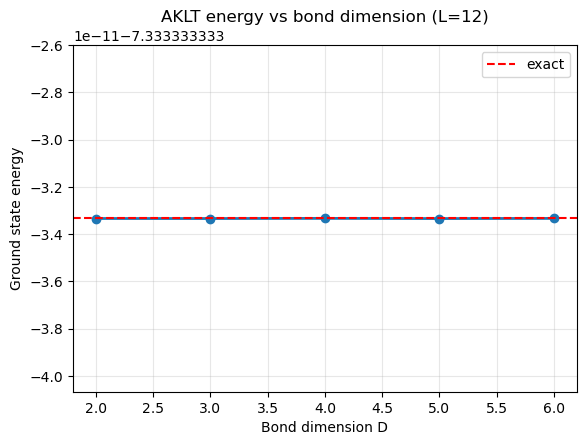

Saved: figureAKLT\07_energy_vs_D.png

=== AKLT: finite-size scaling (energy per bond) ===
Running AKLT DMRG for L=8
  E/(L-1) = -0.666666666667, exact = -0.666666666667
Running AKLT DMRG for L=10
  E/(L-1) = -0.666666666667, exact = -0.666666666667
Running AKLT DMRG for L=12
  E/(L-1) = -0.666666666667, exact = -0.666666666667
Running AKLT DMRG for L=14
  E/(L-1) = -0.666666666667, exact = -0.666666666667
Running AKLT DMRG for L=16
  E/(L-1) = -0.666666666667, exact = -0.666666666667
Running AKLT DMRG for L=20
  E/(L-1) = -0.666666666667, exact = -0.666666666667


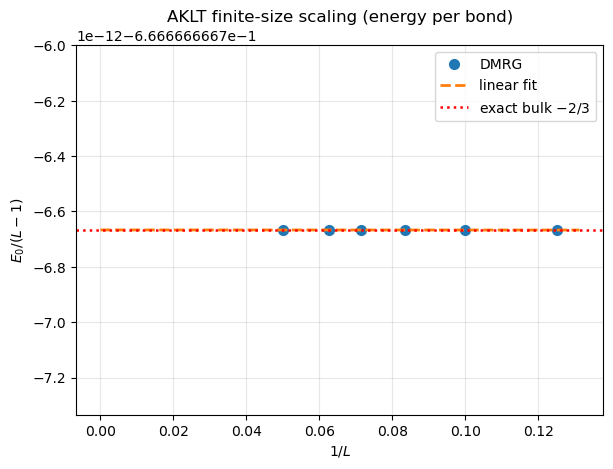

Saved: figureAKLT\08_finite_size_scaling.png
Finite-size extrapolated bond energy = -0.666666666667
Exact bond energy                    = -0.666666666667

=== Spin-1/2 Heisenberg model ===
Running Heisenberg DMRG...
sweep  1 | E = -8.625949658425 | |dE| = inf | norm^2 = 1.000000e+00 | time = 31.89s | solvers = {'eigsh': 38}
sweep  2 | E = -8.682375587239 | |dE| = 5.643e-02 | norm^2 = 1.000000e+00 | time = 39.25s | solvers = {'eigsh': 38}
sweep  3 | E = -8.682472913197 | |dE| = 9.733e-05 | norm^2 = 1.000000e+00 | time = 74.76s | solvers = {'eigsh': 38}
sweep  4 | E = -8.682472913690 | |dE| = 4.923e-10 | norm^2 = 1.000000e+00 | time = 76.69s | solvers = {'eigsh': 38}
sweep  5 | E = -8.682472913690 | |dE| = 5.862e-14 | norm^2 = 1.000000e+00 | time = 76.62s | solvers = {'eigsh': 38}
DMRG converged.

Heisenberg final energy = -8.68247291368974
Heisenberg energy per bond = -0.4569722586152494

Running exact check for Heisenberg L=10...
Heisenberg exact small-chain energy = -4.258035207283
H

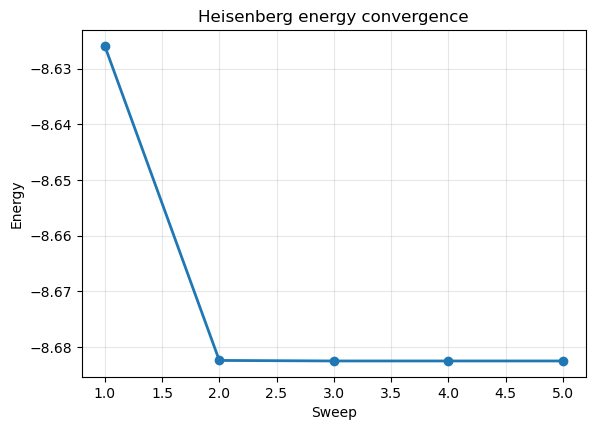

Saved: figureAKLT\12_heisenberg_energy_convergence.png


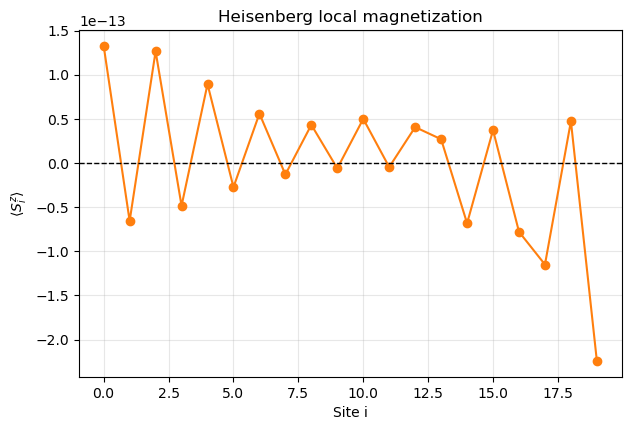

Saved: figureAKLT\13_heisenberg_local_Sz.png


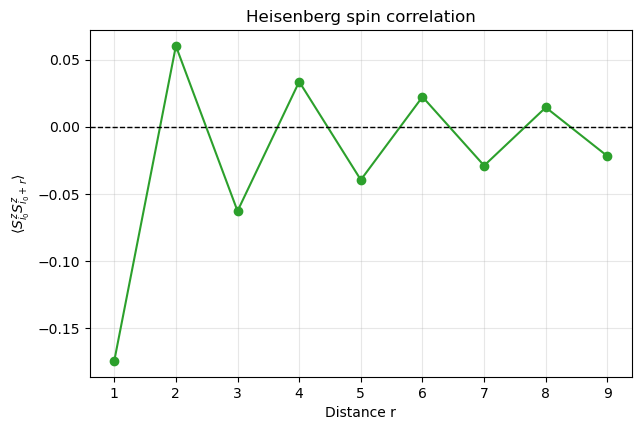

Saved: figureAKLT\14_heisenberg_spin_correlation.png


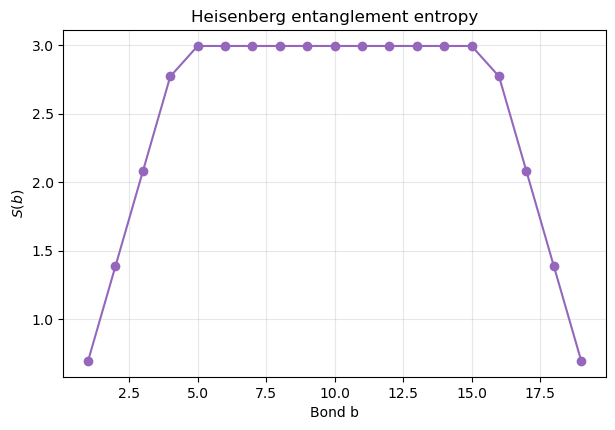

Saved: figureAKLT\15_heisenberg_entanglement_entropy.png


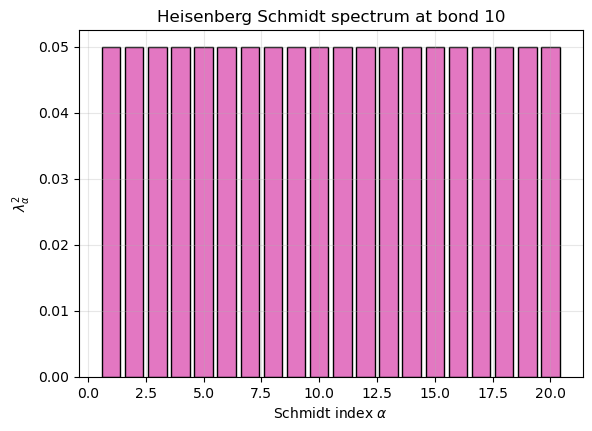

Saved: figureAKLT\16_heisenberg_schmidt_spectrum.png


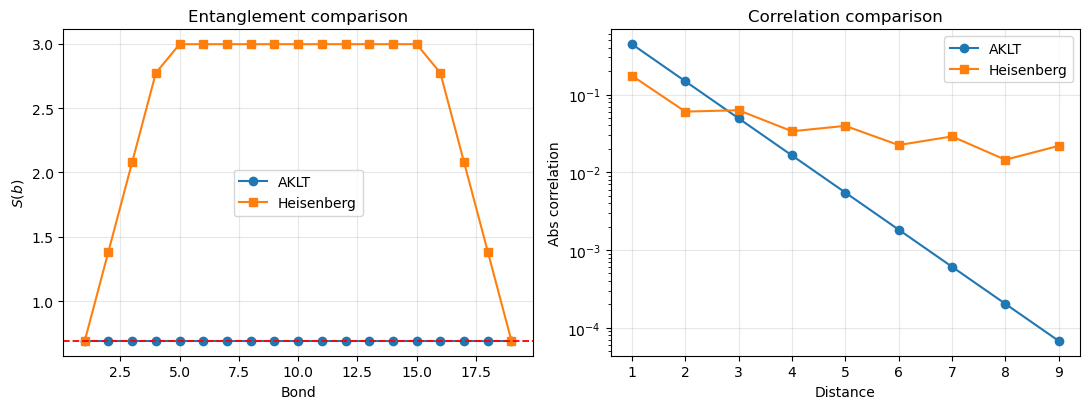

Saved: figureAKLT\17_aklt_vs_heisenberg_comparison.png

Summary
------------------------------------------------------------
AKLT L=20 energy                  = -12.666666666667
AKLT energy per bond              = -0.666666666667
AKLT exact bond energy            = -0.666666666667
Heisenberg L=20 energy            = -8.682472913690
Heisenberg energy per bond        = -0.456972258615
Heisenberg small-L exact check    = -4.258035207283
Heisenberg small-L DMRG check     = -4.258035206806
Heisenberg small-L abs error      = 4.773e-10
Saved figures in directory: figureAKLT


In [5]:
# Cell 5: AKLT scaling and spin-1/2 Heisenberg run

def kron_n(ops):
    out = ops[0]
    for op in ops[1:]:
        out = np.kron(out, op)
    return out


def exact_heisenberg_obc(L, Jx=1.0, Jz=1.0, h=0.0):
    I, Sx, Sy, Sz, Sp, Sm = spin_half_ops()
    d = 2
    H = np.zeros((d**L, d**L), dtype=complex)

    for i in range(L - 1):
        ops = [I] * L
        ops[i] = Sp
        ops[i + 1] = Sm
        H += 0.5 * Jx * kron_n(ops)

        ops = [I] * L
        ops[i] = Sm
        ops[i + 1] = Sp
        H += 0.5 * Jx * kron_n(ops)

        ops = [I] * L
        ops[i] = Sz
        ops[i + 1] = Sz
        H += Jz * kron_n(ops)

    for i in range(L):
        ops = [I] * L
        ops[i] = Sz
        H += h * kron_n(ops)

    evals, evecs = np.linalg.eigh(H)
    return float(np.real(evals[0]))


# ============================================================
# AKLT figure 07: energy vs D
# ============================================================

print("\n=== AKLT: energy vs bond dimension D ===")

L_ed = 12
Ds = [2, 3, 4, 5, 6]
energies_vs_D = []

mpo_L12, _, _ = build_aklt_mpo(L_ed, verbose=False)
E_exact_L12 = -(2.0 / 3.0) * (L_ed - 1)

for D in Ds:
    print(f"Running AKLT DMRG for L={L_ed}, D={D}")
    mps0 = random_mps(L=L_ed, d=3, Dmax=D, seed=100 + D)
    mpsD, ED, histD = dmrg_two_site(
        mps0, mpo_L12,
        Dmax=D,
        nsweeps=5,
        eps_E=1e-12,
        eps_trunc=1e-12,
        eps_abs=1e-14,
        lanczos_tol=1e-12,
        verbose=False
    )
    energies_vs_D.append(ED)
    print(f"  E(D={D}) = {ED:.12f}, error = {abs(ED - E_exact_L12):.3e}")

fig = plt.figure(figsize=(6.5, 4.5))
plt.plot(Ds, energies_vs_D, 'o-', lw=2)
plt.axhline(E_exact_L12, color='red', ls='--', lw=1.5, label='exact')
plt.xlabel("Bond dimension D")
plt.ylabel("Ground state energy")
plt.title("AKLT energy vs bond dimension (L=12)")
plt.legend()
plt.grid(alpha=0.3)
save_show(fig, "07_energy_vs_D.png")


# ============================================================
# AKLT figure 08: finite-size scaling using E/(L-1)
# ============================================================

print("\n=== AKLT: finite-size scaling (energy per bond) ===")

Ls_fss = [8, 10, 12, 14, 16, 20]
energies_per_bond = []
invL = []

for Lf in Ls_fss:
    print(f"Running AKLT DMRG for L={Lf}")
    mpo_f, _, _ = build_aklt_mpo(Lf, verbose=False)
    mps0 = random_mps(L=Lf, d=3, Dmax=5, seed=200 + Lf)
    mpsf, Ef, histf = dmrg_two_site(
        mps0, mpo_f,
        Dmax=5,
        nsweeps=5,
        eps_E=1e-12,
        eps_trunc=1e-12,
        eps_abs=1e-14,
        lanczos_tol=1e-12,
        verbose=False
    )
    energies_per_bond.append(Ef / (Lf - 1))
    invL.append(1.0 / Lf)
    print(f"  E/(L-1) = {Ef/(Lf-1):.12f}, exact = {-2.0/3.0:.12f}")

invL = np.array(invL)
energies_per_bond = np.array(energies_per_bond)

coef = np.polyfit(invL, energies_per_bond, 1)
bulk_extrap = coef[1]

fig = plt.figure(figsize=(6.8, 4.8))
plt.plot(invL, energies_per_bond, 'o', ms=7, label='DMRG')
xx = np.linspace(0, invL.max() * 1.05, 200)
plt.plot(xx, np.polyval(coef, xx), '--', color='tab:orange', lw=2, label='linear fit')
plt.axhline(-2.0 / 3.0, color='red', ls=':', lw=1.8, label='exact bulk $-2/3$')
plt.xlabel(r'$1/L$')
plt.ylabel(r'$E_0/(L-1)$')
plt.title("AKLT finite-size scaling (energy per bond)")
plt.legend()
plt.grid(alpha=0.3)
save_show(fig, "08_finite_size_scaling.png")

print(f"Finite-size extrapolated bond energy = {bulk_extrap:.12f}")
print(f"Exact bond energy                    = {-2.0/3.0:.12f}")


# ============================================================
# Heisenberg production run
# ============================================================

print("\n=== Spin-1/2 Heisenberg model ===")

L_heis = 20
D_heis = 20
nsweeps_heis = 8
Jx = 1.0
Jz = 1.0
h = 0.0

mpo_heis, DW_heis = build_heisenberg_mpo(L_heis, Jx=Jx, Jy=Jx, Jz=Jz, h=h)
mps0_heis = random_mps(L=L_heis, d=2, Dmax=D_heis, seed=4321)

print("Running Heisenberg DMRG...")
mps_heis, E_heis, hist_heis = dmrg_two_site(
    mps0_heis,
    mpo_heis,
    Dmax=D_heis,
    nsweeps=nsweeps_heis,
    eps_E=1e-10,
    eps_trunc=1e-10,
    eps_abs=1e-14,
    lanczos_tol=1e-10,
    verbose=True
)

print("\nHeisenberg final energy =", E_heis)
print("Heisenberg energy per bond =", E_heis / (L_heis - 1))


# ============================================================
# Small exact check for Heisenberg
# ============================================================

L_heis_small = 10
print(f"\nRunning exact check for Heisenberg L={L_heis_small}...")
E_heis_exact_small = exact_heisenberg_obc(L_heis_small, Jx=1.0, Jz=1.0, h=0.0)

mpo_heis_small, _ = build_heisenberg_mpo(L_heis_small, Jx=1.0, Jy=1.0, Jz=1.0, h=0.0)
mps0_heis_small = random_mps(L=L_heis_small, d=2, Dmax=20, seed=777)

mps_heis_small, E_heis_small, hist_heis_small = dmrg_two_site(
    mps0_heis_small,
    mpo_heis_small,
    Dmax=20,
    nsweeps=8,
    eps_E=1e-10,
    eps_trunc=1e-10,
    eps_abs=1e-14,
    lanczos_tol=1e-10,
    verbose=False
)

print(f"Heisenberg exact small-chain energy = {E_heis_exact_small:.12f}")
print(f"Heisenberg DMRG  small-chain energy = {E_heis_small:.12f}")
print(f"Absolute error                      = {abs(E_heis_small - E_heis_exact_small):.3e}")


# ============================================================
# Heisenberg observables
# ============================================================

I2, Sx2, Sy2, Sz2, Sp2, Sm2 = spin_half_ops()

sites_h = np.arange(L_heis)
local_Sz_h = np.array([expectation(mps_heis, Sz2, i) for i in range(L_heis)])

center_h = L_heis // 2
distances_h = np.arange(1, L_heis - center_h)
corr_h = np.array([correlator(mps_heis, Sz2, Sz2, center_h, center_h + r) for r in distances_h])
corr_abs_h = np.abs(corr_h)

entropy_bonds_h = np.arange(1, L_heis)
entropy_vals_h = entanglement_profile(mps_heis)

bond_center_h = L_heis // 2
schmidt_h = schmidt_values_at_bond(mps_heis, bond_center_h)
schmidt_w_h = schmidt_h**2


# ============================================================
# Heisenberg figures
# ============================================================

fig = plt.figure(figsize=(6.5, 4.5))
plt.plot(hist_heis["sweep"], hist_heis["energy"], 'o-', lw=2, color='tab:blue')
plt.xlabel("Sweep")
plt.ylabel("Energy")
plt.title("Heisenberg energy convergence")
plt.grid(alpha=0.3)
save_show(fig, "12_heisenberg_energy_convergence.png")

fig = plt.figure(figsize=(7, 4.5))
plt.plot(sites_h, local_Sz_h, 'o-', color='tab:orange')
plt.axhline(0.0, color='k', ls='--', lw=1)
plt.xlabel("Site i")
plt.ylabel(r'$\langle S^z_i \rangle$')
plt.title("Heisenberg local magnetization")
plt.grid(alpha=0.3)
save_show(fig, "13_heisenberg_local_Sz.png")

fig = plt.figure(figsize=(7, 4.5))
plt.plot(distances_h, corr_h, 'o-', color='tab:green')
plt.axhline(0.0, color='k', ls='--', lw=1)
plt.xlabel("Distance r")
plt.ylabel(r'$\langle S^z_{i_0}S^z_{i_0+r}\rangle$')
plt.title("Heisenberg spin correlation")
plt.grid(alpha=0.3)
save_show(fig, "14_heisenberg_spin_correlation.png")

fig = plt.figure(figsize=(7, 4.5))
plt.plot(entropy_bonds_h, entropy_vals_h, 'o-', color='tab:purple')
plt.xlabel("Bond b")
plt.ylabel(r'$S(b)$')
plt.title("Heisenberg entanglement entropy")
plt.grid(alpha=0.3)
save_show(fig, "15_heisenberg_entanglement_entropy.png")

fig = plt.figure(figsize=(6.5, 4.5))
plt.bar(np.arange(1, len(schmidt_w_h) + 1), schmidt_w_h, color='tab:pink', edgecolor='k')
plt.xlabel(r'Schmidt index $\alpha$')
plt.ylabel(r'$\lambda_\alpha^2$')
plt.title(f"Heisenberg Schmidt spectrum at bond {bond_center_h}")
plt.grid(alpha=0.3)
save_show(fig, "16_heisenberg_schmidt_spectrum.png")


# ============================================================
# Comparison panel
# ============================================================

fig, axs = plt.subplots(1, 2, figsize=(11, 4.2))

axs[0].plot(entropy_bonds, entropy_vals, 'o-', label='AKLT')
axs[0].plot(entropy_bonds_h, entropy_vals_h, 's-', label='Heisenberg')
axs[0].axhline(np.log(2.0), color='red', ls='--', lw=1.3)
axs[0].set_xlabel("Bond")
axs[0].set_ylabel(r'$S(b)$')
axs[0].set_title("Entanglement comparison")
axs[0].legend()
axs[0].grid(alpha=0.3)

axs[1].semilogy(distances, corr_abs, 'o-', label='AKLT')
axs[1].semilogy(distances_h, np.maximum(corr_abs_h, 1e-16), 's-', label='Heisenberg')
axs[1].set_xlabel("Distance")
axs[1].set_ylabel("Abs correlation")
axs[1].set_title("Correlation comparison")
axs[1].legend()
axs[1].grid(alpha=0.3)

plt.tight_layout()
save_show(fig, "17_aklt_vs_heisenberg_comparison.png")


# ============================================================
# Final summary
# ============================================================

print("\nSummary")
print("-" * 60)
print(f"AKLT L=20 energy                  = {E_aklt:.12f}")
print(f"AKLT energy per bond              = {E_aklt/(L_aklt-1):.12f}")
print(f"AKLT exact bond energy            = {-2.0/3.0:.12f}")
print(f"Heisenberg L=20 energy            = {E_heis:.12f}")
print(f"Heisenberg energy per bond        = {E_heis/(L_heis-1):.12f}")
print(f"Heisenberg small-L exact check    = {E_heis_exact_small:.12f}")
print(f"Heisenberg small-L DMRG check     = {E_heis_small:.12f}")
print(f"Heisenberg small-L abs error      = {abs(E_heis_small - E_heis_exact_small):.3e}")
print(f"Saved figures in directory: {FIGDIR}")